<a href="https://colab.research.google.com/github/Shambhuraje1919/Machine_Learning_Paractice/blob/main/catVSDog_minidataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aleemaparakatta/cats-and-dogs-mini-dataset")

print("Path to dataset files:", path)

100%|██████████| 21.9M/21.9M [00:02<00:00, 10.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/aleemaparakatta/cats-and-dogs-mini-dataset/versions/1


In [2]:
import os
os.listdir(path)

['cats_set', 'dogs_set']

In [3]:
path

'/root/.cache/kagglehub/datasets/aleemaparakatta/cats-and-dogs-mini-dataset/versions/1'

In [4]:
import pandas as pd

In [5]:
from torchvision import datasets , transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(
    root = "/root/.cache/kagglehub/datasets/aleemaparakatta/cats-and-dogs-mini-dataset/versions/1",
    transform=transform
)




In [6]:


print(dataset)

Dataset ImageFolder
    Number of datapoints: 1000
    Root location: /root/.cache/kagglehub/datasets/aleemaparakatta/cats-and-dogs-mini-dataset/versions/1
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )


In [7]:
print(dataset.classes)
print(dataset.class_to_idx)

['cats_set', 'dogs_set']
{'cats_set': 0, 'dogs_set': 1}


In [8]:
dataset[0]

(tensor([[[0.0745, 0.2667, 0.2824,  ..., 0.2157, 0.2118, 0.0392],
          [0.1137, 0.4431, 0.5098,  ..., 0.4000, 0.3137, 0.0588],
          [0.1059, 0.4549, 0.5843,  ..., 0.4000, 0.2627, 0.0510],
          ...,
          [0.1137, 0.4039, 0.3843,  ..., 0.2588, 0.2235, 0.0431],
          [0.0706, 0.2627, 0.2431,  ..., 0.1765, 0.1647, 0.0353],
          [0.0118, 0.0431, 0.0588,  ..., 0.0235, 0.0235, 0.0078]],
 
         [[0.0588, 0.1961, 0.2275,  ..., 0.1882, 0.1882, 0.0314],
          [0.0980, 0.3647, 0.4510,  ..., 0.3882, 0.2980, 0.0549],
          [0.0902, 0.3804, 0.5333,  ..., 0.4196, 0.2627, 0.0510],
          ...,
          [0.1020, 0.3569, 0.3333,  ..., 0.2706, 0.2353, 0.0471],
          [0.0784, 0.2431, 0.2000,  ..., 0.1843, 0.1765, 0.0353],
          [0.0353, 0.0392, 0.0353,  ..., 0.0275, 0.0353, 0.0078]],
 
         [[0.0588, 0.2353, 0.2745,  ..., 0.2078, 0.2039, 0.0431],
          [0.0902, 0.4000, 0.4941,  ..., 0.4157, 0.3216, 0.0627],
          [0.0784, 0.4000, 0.5647,  ...,

In [9]:
len(dataset)

1000

In [10]:
import matplotlib.pyplot as plt


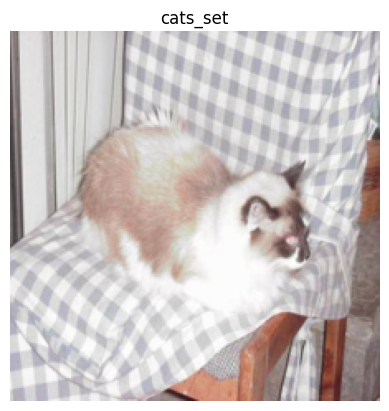

In [11]:
image,label = dataset[10]

plt.imshow(image.permute(1,2,0))
plt.title(dataset.classes[label])
plt.axis('off')
plt.show()


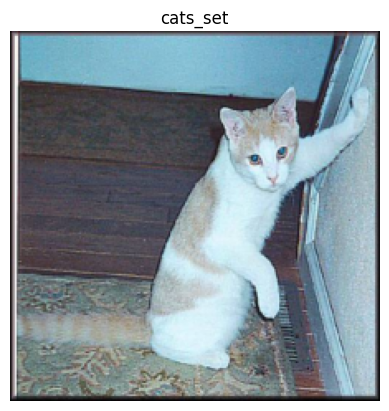

In [12]:
image , label = dataset[0]

plt.imshow(image.permute(1,2,0))
plt.title(dataset.classes[label])
plt.axis('off')
plt.show()

In [13]:
from torch.utils.data import random_split

train_size = int(0.8 * len(dataset))
test_size = len(dataset)-train_size

train_dataset , test_dataset = random_split(dataset, [train_size,test_size])

In [14]:
train_loader = DataLoader(train_dataset , shuffle=True , batch_size=32)
test_loader = DataLoader(test_dataset , shuffle = True , batch_size=32)

In [15]:
len(train_loader)

25

In [16]:
200/32

6.25

In [17]:
len(test_loader)

7

In [18]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [19]:
import torch.nn as nn
import torch

In [41]:
class MyCnn(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(
        in_channels=3, ## the RGB chaneel thats why its 3
        out_channels=32,  #out channel means it can diffentiate  thing from image like edges , eyes,furs ->32 diff things
        padding=1,     # add 0 boundry
        kernel_size=3)   #add the moving  □ □ □ , It slides across the image and extracts features."""
    self.ReLU = nn.ReLU()

    self.pool  = nn.MaxPool2d(kernel_size=2,stride=2) ## pooling moving forwrad

    self.conv2 = nn.Conv2d(
        in_channels= 32,
        out_channels=64,
        padding= 1,
        kernel_size=3

    )

    self.fc1 = nn.Linear(64 * 56 * 56 , 128)
    self.fc2 = nn.Linear(128,2)

  def forward(self ,x):

    x = self.conv1(x)
    x = self.ReLU(x)
    x = self.pool(x)

    x = self.conv2(x)
    x = self.ReLU(x)
    x = self.pool(x)
   # print(x.shape)

    x = torch.flatten(x , start_dim =1)
    #print(x.shape)
    x = self.fc1(x)
    x = self.ReLU(x)

    x = self.fc2(x)

    return x





In [42]:
model = MyCnn()

In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MyCnn().to(device)
print(device)

cuda


In [44]:
criterion = nn.CrossEntropyLoss()

In [45]:
epochs = 10
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

In [52]:
for epoch in range(epochs):
    epoch_loss = 0

    for i, (image, label) in enumerate(train_loader):

        image = image.to(device)
        label = label.to(device)

        output = model(image)
        loss = criterion(output, label)

        if i == 0:
            print("First batch loss:", loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print("Average epoch loss:", epoch_loss / len(train_loader))

First batch loss: 8.322628127643839e-05
Average epoch loss: 7.960650960740167e-05
First batch loss: 6.909185322001576e-05
Average epoch loss: 7.27814482524991e-05
First batch loss: 0.00010041877976618707
Average epoch loss: 6.748046820575837e-05
First batch loss: 0.0001024785015033558
Average epoch loss: 6.360853665682954e-05
First batch loss: 1.8797130906023085e-05
Average epoch loss: 5.751259814132936e-05
First batch loss: 3.9912611100589857e-05
Average epoch loss: 5.43073227891e-05
First batch loss: 5.0505768740549684e-05
Average epoch loss: 5.06508004036732e-05
First batch loss: 6.83262333041057e-05
Average epoch loss: 4.6586757380282504e-05
First batch loss: 7.328357605729252e-05
Average epoch loss: 4.3802263535326345e-05
First batch loss: 3.629720231401734e-05
Average epoch loss: 4.086753870069515e-05


In [51]:
print("Number of batches:", len(train_loader))
print("Dataset size:", len(train_loader.dataset))
print("Batch size:", train_loader.batch_size)

Number of batches: 25
Dataset size: 800
Batch size: 32


In [39]:
model.eval()

MyCnn(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (ReLU): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=200704, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
)

In [53]:


correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)

        # Get predicted class
        _, predicted = torch.max(outputs, 1)

        # Count correct predictions
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 56.50%
